# Store Sales Forecasting (all family - 1 store)

## Цель - Построить имодель прогнозирования продаж на уровне товарных категорий, сравнив:
- Baseline (лаг 31 день)
- ML-модель (CatBoost)
- Пост-обработку для категорий с нулевым спросом

## Данные
- `train.csv` — продажи
- `holidays_events.csv` — праздники
- `oil.csv` — цена нефти

## Pipeline
1. Подготовка временного ряда
2. Feature Engineering
3. Baseline прогноз
4. Обучение CatBoost
5. Анализ ошибок
6. Стратегия zero-forecast для редких продаж

## Итоговые метрики (Март 2016)

Overall WAPE = **0.103** 
| Overall MAE = **33.77**

## Ключевые инсайты
- ML-модель снижает WAPE на ~74%.
- Категории с >90% нулевых продаж требуют отдельной логики.
- Простая пост-обработка может улучшить метрики без переобучения модели.

---


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, CatBoostClassifier
from sklearn.preprocessing import LabelEncoder 

####################################################
# 1. Загрузка данных
####################################################

data_path = '/kaggle/input/store-sales-time-series-forecasting/'
sales = pd.read_csv(data_path + 'train.csv')
stores = pd.read_csv(data_path + 'stores.csv')
holidays = pd.read_csv(data_path + 'holidays_events.csv')
oil = pd.read_csv(data_path + 'oil.csv')

sales['date'] = pd.to_datetime(sales['date'])
holidays['date'] = pd.to_datetime(holidays['date'])
oil['date'] = pd.to_datetime(oil['date'])


####################################################
# 2. Подготовка данных
####################################################
mask = (sales['date'] < '2016-04-01') & (sales['store_nbr'] == 1)
df = sales[mask].copy()

# создаем полный календарь
full_dates = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
calendar_df = pd.DataFrame({'date': full_dates})

df = calendar_df.merge(df, on='date', how='left')

# заполняем пропуски
df['sales'] = df['sales'].fillna(0)
df['onpromotion'] = df['onpromotion'].fillna(0)

# агрегируем до уровня дня
df = df.groupby(['family', 'date'], as_index=False).agg({
    'sales': 'sum',
    'onpromotion': 'sum'
})

# Кодирование 'family'
le = LabelEncoder()
df['family'] = le.fit_transform(df['family'].astype(str))

df.head()

,family,date,sales,onpromotion
0,0,2013-01-01,0.0,0.0
1,0,2013-01-02,2.0,0.0
2,0,2013-01-03,3.0,0.0
3,0,2013-01-04,3.0,0.0
4,0,2013-01-05,5.0,0.0


In [95]:
####################################################
# 3. Baseline прогноз и оценка
####################################################

# 1. Создаем признак прогноза (лаг на 31 день внутри каждой категории)
df['baseline_pred'] = df.groupby('family')['sales'].shift(31)

# 2. Выделяем период оценки (Март 2016)
march_mask = (df['date'] >= '2016-03-01') & (df['date'] <= '2016-03-31')
df_march = df[march_mask].copy()

# Удаляем строки, где нет значения прогноза (первые 31 день)
df_march = df_march.dropna(subset=['baseline_pred'])

# 3. Считаем абсолютную ошибку
df_march['abs_error'] = (df_march['sales'] - df_march['baseline_pred']).abs()

# 4. Агрегируем данные по категориям для расчета WAPE
# WAPE = Sum(|Actual - Predicted|) / Sum(Actual)
agg_stats = df_march.groupby('family').agg({
    'sales': 'sum',          # Сумма фактических продаж (знаменатель)
    'abs_error': 'sum'       # Сумма абсолютных ошибок (числитель)
})

# Избегаем деления на ноль
agg_stats['baseline'] = agg_stats.apply(
    lambda x: x['abs_error'] / x['sales'] if x['sales'] > 0 else 0.0, 
    axis=1
)

# 5. Рассчитываем общую метрику (Overall WAPE)
total_sales = agg_stats['sales'].sum()
total_error = agg_stats['abs_error'].sum()
overall_wape = total_error / total_sales if total_sales > 0 else 0.0

print(f"Общий WAPE baseline прогноза на Март 2016: {overall_wape:.4f}")
print('Это бвзовый уровень качества прогноза, который будет улучшен.')
# 6. Формируем итоговый датафрейм wape_df
# Строки - названия категорий (индекс), Колонка - baseline
wape_df = agg_stats[['baseline']].copy()

Общий WAPE baseline прогноза на Март 2016: 0.3963
Это бвзовый уровень качества прогноза, который будет улучшен.


In [96]:
####################################################
# 4. Feature Engineering
####################################################

# 4.1 Сохраняем реальные продажи для оценки прогноза
df['real_sales'] = df['sales'].copy()

# 4.2 Логарифмирование таргета (log1p уже добавляет 1, поэтому +1 не нужен)
df['sales'] = np.log1p(df['sales'])
df = df.sort_values(['family', 'date']).reset_index(drop=True)


# --- 4.3 Календарные признаки ---
df['dow'] = df['date'].dt.dayofweek
df['is_weekend'] = df['dow'].isin([5, 6]).astype(int)
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['year'] = df['date'].dt.year


# --- 4.4 Исторические признаки (лаги и скользящие средние) ---
lags = [1, 3, 7, 14, 28]
for lag in lags:
    df[f'sales_lag_{lag}'] = df.groupby('family')['sales'].shift(lag)

windows = [7, 14, 28]
for w in windows:
    # Среднее продаж за окно
    df[f'sales_mean_{w}'] = (
        df.groupby('family')['sales']
          .shift(1)
          .rolling(w)
          .mean()
          .reset_index(level=0, drop=True)
    )
    
    # Стандартное отклонение продаж за окно
    df[f'sales_std_{w}'] = (
        df.groupby('family')['sales']
          .shift(1)
          .rolling(w)
          .std()
          .reset_index(level=0, drop=True)
    )
    
    # Среднее промо за окно
    df[f'promo_mean_{w}'] = (
        df.groupby('family')['onpromotion']
          .shift(1)
          .rolling(w)
          .mean()
          .reset_index(level=0, drop=True)
    )
    
    # Стандартное отклонение промо за окно (ИСПРАВЛЕНО: было sales_std вместо promo_std)
    df[f'promo_std_{w}'] = (
        df.groupby('family')['onpromotion']
          .shift(1)
          .rolling(w)
          .std()
          .reset_index(level=0, drop=True)
    )
    
    # Доля промо-дней за последние W дней
    df[f'promo_ratio_{w}'] = (
        df.groupby('family')['onpromotion']
          .transform(lambda x: (x != 0).astype(int).shift(1).rolling(w).mean())
    )


# --- 4.5 Признаки давности продаж (recency features) ---
# days_since_last_sale — дни с последней НЕНУЛЕВОЙ продажи
def compute_days_since_last_sale(group):
    result = []
    last_sale_day = None
    
    for i, val in enumerate(group.shift(1)):  # shift(1) чтобы не заглядывать в будущее
        if val is not None and val > 0:
            last_sale_day = i
            result.append(0)
        else:
            if last_sale_day is None:
                result.append(np.nan)
            else:
                result.append(i - last_sale_day)
    
    return pd.Series(result, index=group.index)

df['days_since_last_sale'] = (
    df.groupby('family')['sales']
    .transform(compute_days_since_last_sale)
)
    
# last_nonzero_qty — величина последней ненулевой продажи в прошлом
df['last_nonzero_qty'] = (
    df.groupby('family')['sales']
      .transform(lambda x: x.shift(1).where(x.shift(1) > 0).ffill())
)


# --- 4.6 Календарь праздников ---
holidays['date'] = pd.to_datetime(holidays['date'])
df = df.merge(holidays[['date', 'type', 'locale']], on='date', how='left')
df['type'] = df['type'].fillna('Work Day')
df['locale'] = df['locale'].fillna('unknown')

# Дни до/после праздников
for d in [3, 7]:
    holidays_dates = holidays[holidays['type'] == 'Holiday']['date']
    
    df[f'{d}_days_to_holiday'] = df['date'].isin(holidays_dates - pd.Timedelta(days=d)).astype(int)
    df[f'{d}_days_after_holiday'] = df['date'].isin(holidays_dates + pd.Timedelta(days=d)).astype(int)


# --- 4.7 Цена нефти ---
oil['date'] = pd.to_datetime(oil['date'])
df = df.merge(oil[['date', 'dcoilwtico']], on='date', how='left')
df['dcoilwtico'] = df['dcoilwtico'].ffill().bfill()  # заполняем пропуски в начале тоже


# 4.8 Кодирование категориальных признаков
cat_cols = ['type', 'locale']
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# 4.9 Удаление строк с NaN
df = df.dropna().reset_index(drop=True)

print(f"Итоговый размер датасета: {df.shape}")


Итоговый размер датасета: (32887, 41)


Train: 2013-02-01 00:00:00 — 2016-02-29 00:00:00 | (31926, 41)
Test:  2016-03-01 00:00:00 — 2016-03-31 00:00:00 | (961, 41)
0:	learn: 2.1775085	total: 27.8ms	remaining: 13.9s
100:	learn: 0.4710563	total: 2.15s	remaining: 8.48s
200:	learn: 0.4358965	total: 4.07s	remaining: 6.05s
300:	learn: 0.4145547	total: 6.02s	remaining: 3.98s
400:	learn: 0.3975477	total: 8.08s	remaining: 1.99s
499:	learn: 0.3854770	total: 10.1s	remaining: 0us

Общий WAPE ML_v1 на Март 2016: 0.1035

WAPE по категориям (baseline vs ML_v1):
         baseline     ML_v1  improvement  improvement_pct
0        0.577381  0.507279     0.070102            12.14
1        0.000000  0.000000     0.000000              NaN
2        0.842105  0.518564     0.323542            38.42
3        0.313200  0.074138     0.239062            76.33
4        0.000000  0.000000     0.000000              NaN
5        0.349158  0.107096     0.242063            69.33
6        0.866828  0.367395     0.499434            57.62
7        0.452188  0.11

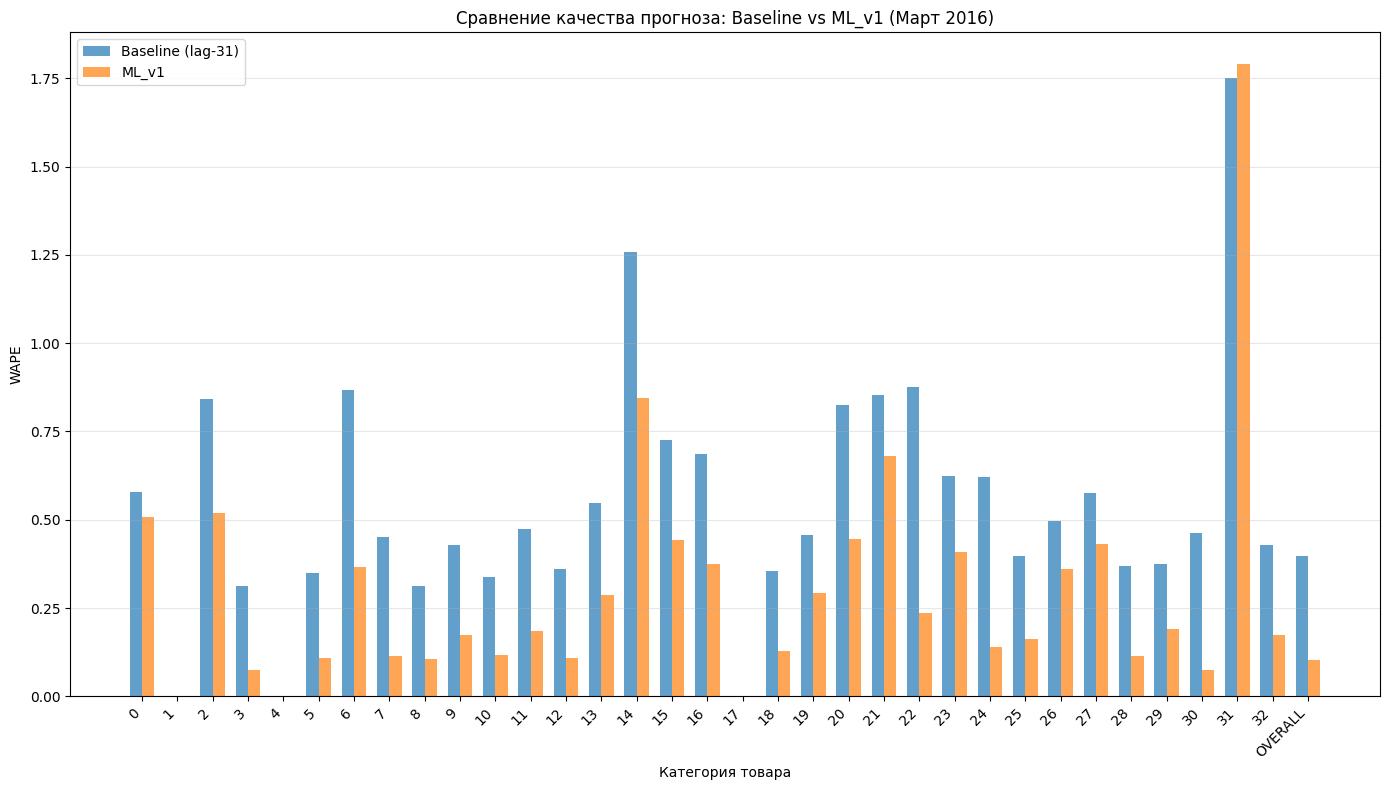

In [97]:
####################################################
# 5. Обучение модели CatBoost и оценка качества
####################################################

# 5.1 Разделение на train и test
test_mask = (df['date'] >= '2016-03-01') & (df['date'] <= '2016-03-31')
train_mask = df['date'] < '2016-03-01'

df_train = df[train_mask].copy()
df_test = df[test_mask].copy()

print(f"Train: {df_train['date'].min()} — {df_train['date'].max()} | {df_train.shape}")
print(f"Test:  {df_test['date'].min()} — {df_test['date'].max()} | {df_test.shape}")

# 5.2 Признаки и таргет
exclude_cols = ['sales', 'real_sales', 'date', 'baseline_pred', 'abs_error']
feature_cols = [col for col in df.columns if col not in exclude_cols]
cat_features = ['family', 'type', 'locale']

X_train = df_train[feature_cols]
y_train = df_train['sales']

X_test = df_test[feature_cols]
y_test = df_test['sales']
y_test_real = df_test['real_sales']

# 5.3 Обучение CatBoost
model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    loss_function='RMSE',
    cat_features=cat_features,
    verbose=100,
    random_seed=42
)

model.fit(X_train, y_train)

# 5.4 Прогноз и обратное преобразование
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_pred = np.maximum(y_pred, 0)

df_test['prediction'] = y_pred
df_test['abs_error'] = (df_test['real_sales'] - df_test['prediction']).abs()

test_stats = df_test.groupby('family').agg({
    'real_sales': 'sum',
    'abs_error': 'sum'
})

test_stats['ML_v1'] = test_stats.apply(
    lambda x: x['abs_error'] / x['real_sales'] if x['real_sales'] > 0 else 0.0,
    axis=1
)

# 5.6 Общая метрика ML_v1
total_sales_test = test_stats['real_sales'].sum()
total_error_test = test_stats['abs_error'].sum()
overall_wape_ml = total_error_test / total_sales_test if total_sales_test > 0 else 0.0

print(f"\n{'='*60}")
print(f"Общий WAPE ML_v1 на Март 2016: {overall_wape_ml:.4f}")
print(f"{'='*60}")

# 5.7 Объединяем baseline и ML_v1 (теперь индексы совпадают - оба family_name)
wape_df = wape_df.merge(
    test_stats[['ML_v1']],
    left_index=True,
    right_index=True,
    how='left'
)

# Заполняем NaN для категорий, которых не было в тесте
wape_df['ML_v1'] = wape_df['ML_v1'].fillna(wape_df['baseline'])

# Добавляем общую метрику
overall_row = pd.DataFrame({
    'baseline': [overall_wape],
    'ML_v1': [overall_wape_ml]
}, index=['OVERALL'])

wape_df = pd.concat([wape_df, overall_row])

# Метрики улучшения
wape_df['improvement'] = wape_df['baseline'] - wape_df['ML_v1']
wape_df['improvement_pct'] = (
    wape_df['improvement'] / wape_df['baseline'].replace(0, np.nan) * 100
).round(2)

print("\nWAPE по категориям (baseline vs ML_v1):")
print(wape_df.to_string())

# 5.8 Визуализация
plt.figure(figsize=(14, 8))
x = np.arange(len(wape_df))
width = 0.35

plt.bar(x - width/2, wape_df['baseline'], width, label='Baseline (lag-31)', alpha=0.7)
plt.bar(x + width/2, wape_df['ML_v1'], width, label='ML_v1', alpha=0.7)

plt.xlabel('Категория товара')
plt.ylabel('WAPE')
plt.title('Сравнение качества прогноза: Baseline vs ML_v1 (Март 2016)')
plt.xticks(x, wape_df.index, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [102]:
####################################################
# 6. Анализ категории 31 и стратегия обнуления
####################################################

# 6.1 Проверка гипотезы: доля нулевых продаж в категории 31
# Получаем данные только для категории 31 (encoded label 31)
cat_31_data = df_test[df_test['family'] == 31].copy()

total_days_cat31 = len(cat_31_data)
zero_sales_days_cat31 = (cat_31_data['real_sales'] == 0).sum()
zero_share_cat31 = zero_sales_days_cat31 / total_days_cat31

print(f"\n{'='*60}")
print(f"Анализ категории 31 (encoded label):")
print(f"Доля дней с нулевой продажей: {zero_share_cat31:.2%}")
print(f"{'='*60}\n")

# 6.2 Обнуление прогнозов для категории 31
df_test_v2 = df_test.copy()
df_test_v2.loc[df_test_v2['family'] == 31, 'prediction'] = 0

# Пересчитываем абсолютную ошибку
df_test_v2['abs_error_v2'] = (df_test_v2['real_sales'] - df_test_v2['prediction']).abs()

# 6.3 Пересчет WAPE для категории 31 и общий WAPE
# Агрегация для новой версии
test_stats_v2 = df_test_v2.groupby('family').agg({
    'real_sales': 'sum',
    'abs_error_v2': 'sum'
})

# WAPE по категориям
test_stats_v2['ML_v2_WAPE'] = test_stats_v2.apply(
    lambda x: x['abs_error_v2'] / x['real_sales'] if x['real_sales'] > 0 else 0.0,
    axis=1
)

# Общий WAPE
total_sales_v2 = test_stats_v2['real_sales'].sum()
total_error_v2 = test_stats_v2['abs_error_v2'].sum()
overall_wape_v2 = total_error_v2 / total_sales_v2 if total_sales_v2 > 0 else 0.0

# Получаем старые значения для сравнения
wape_cat31_old = wape_df.loc[31, 'ML_v1'] if 31 in wape_df.index else None
wape_cat31_new = test_stats_v2.loc[31, 'ML_v2_WAPE'] if 31 in test_stats_v2.index else None

print(f"WAPE Категория 31 (ML_v1): {wape_cat31_old:.4f}")
print(f"WAPE Категория 31 (ML_v2 Zero): {wape_cat31_new:.4f}")
print(f"Общий WAPE (ML_v1): {overall_wape_ml:.4f}")
print(f"Общий WAPE (ML_v2 Zero): {overall_wape_v2:.4f}")


Анализ категории 31 (encoded label):
Доля дней с нулевой продажей: 90.32%

WAPE Категория 31 (ML_v1): 1.7909
WAPE Категория 31 (ML_v2 Zero): 1.0000
Общий WAPE (ML_v1): 0.1035
Общий WAPE (ML_v2 Zero): 0.1035


## Выводы:
* Обнуление прогнозов продаж для категорий с большим количеством нулевых продаж улучшает показатели WAPE по этой категории, но не влияет на общую оценку, так как малое количество продаж слабо влияет на расчет WAPE.
* Простая модель CatBoostRegressor демонстрирует хороший результат, прогнозируя WAPE на уровне 0.1035. Это означает, что модель ошибается в среднем на 10% от реальных продаж.
* Прогноз улучшен на 73% по сравнению с наивным прогнозом (лаг 31).

Также были использованы другие методы прогнозирования: двухэтапный прогноз для категорий товаров с большим количеством нулевых дней, прогнозирование для групп товаров, добавление дополнительных признаков. Однако результаты оказались хуже. Модели переобучались, и качество оценки ухудшалось. Поэтому остановились на текущей архитектуре прогнозирования.